<a href="https://colab.research.google.com/github/onishiryo/KeiRikiKiso/blob/main/Day2%E8%AA%AC%E6%98%8E%E7%94%A8_1D%E3%83%9D%E3%83%AF%E3%82%BD%E3%83%B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1次元ポワソン方程式の解法
$$
\frac{d^2 T(x)}{dx^2}=q(x)
$$
$$0\leq x \leq2\pi, q(x)=sin(x)$$
境界条件：$$T(x=0)=0, T(x=2\pi)=0$$
中心差分法を使って解く。

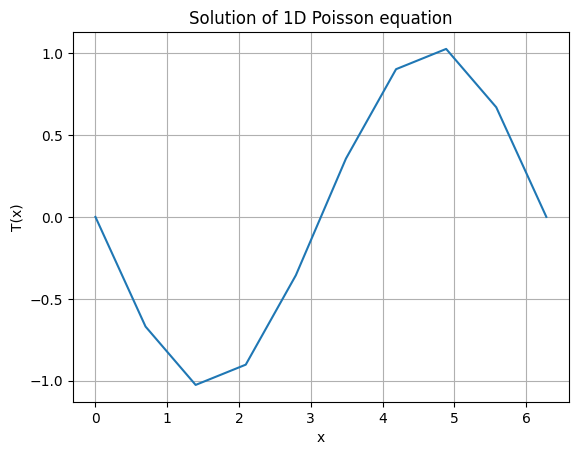

In [6]:
# prompt: 一次元ポワソン方程式を中心差分法を使って解くコード。ガウスの消去法を使う。T(x)をプロットする。numpyは使わない。

import math #to use sin function
import matplotlib.pyplot as plt #to draw graph

# 定数
N = 10  # 格子点数
L = 2 * 3.141592653589793  # 領域の長さ
dx = L / (N - 1)  # 格子間隔

# q(x) の定義
def q(x):
  return math.sin(x)

# 行列Aとベクトルbの初期化
A = [[0.0 for _ in range(N)] for _ in range(N)]
b = [0.0 for _ in range(N)]

# 行列Aとベクトルbの作成
for i in range(1, N - 1):
  A[i][i - 1] = 1.0
  A[i][i] = -2.0
  A[i][i + 1] = 1.0
  b[i] = q(i * dx) * dx**2

# 境界条件
A[0][0] = 1.0
b[0] = 0.0
A[N - 1][N - 1] = 1.0
b[N - 1] = 0.0

# ガウスの消去法
# 前進消去
for k in range(N - 1):
  factor = A[k + 1][k] / A[k][k]
  A[k + 1][k] = 0.0
  for j in range(k + 1, N):
    A[k + 1][j] = A[k + 1][j] - factor * A[k][j]
  b[k + 1] = b[k + 1] - factor * b[k]

# 後退代入
T = [0.0 for _ in range(N)]
T[N - 1] = b[N - 1] / A[N - 1][N - 1]
for i in range(N - 2, -1, -1):
  sum_term = 0.0
  for j in range(i + 1, N):
    sum_term += A[i][j] * T[j]
  T[i] = (b[i] - sum_term) / A[i][i]


# プロット
x = [i * dx for i in range(N)]
plt.plot(x, T)
plt.xlabel('x')
plt.ylabel('T(x)')
plt.title('Solution of 1D Poisson equation')
plt.grid(True)
plt.show()